# Module 1, Lab 3 — Textbook Problem 1.2
## Choosing an auto insurance provider

**Name:** Mac Mckay
**Course:** Module 1 — What Is Data Science / Setting Up Your Toolkit

---

**The problem.** Three auto insurance providers, three customer ratings each (out of 10). Pick one and defend the choice.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "provider": ["GEICO"] * 3 + ["Progressive"] * 3 + ["USAA"] * 3,
    "rating":   [4.7, 8.3, 9.2, 7.4, 6.7, 8.9, 3.8, 6.3, 8.1],
})

df

,provider,rating
0,GEICO,4.7
1,GEICO,8.3
2,GEICO,9.2
3,Progressive,7.4
4,Progressive,6.7
5,Progressive,8.9
6,USAA,3.8
7,USAA,6.3
8,USAA,8.1


## Min, mean, max

In [2]:
summary = df.groupby("provider")["rating"].agg(["min", "mean", "max", "std"])
summary["range"] = summary["max"] - summary["min"]
summary.round(2)


,min,mean,max,std,range
provider,,,,,
GEICO,4.7,7.40,9.2,2.38,4.5
Progressive,6.7,7.67,8.9,1.12,2.2
USAA,3.8,6.07,8.1,2.16,4.3


## Ranking by min, mean max


In [3]:
ranks = pd.DataFrame({
    "by_mean":  summary["mean"].rank(ascending=False).astype(int),
    "by_min":   summary["min"].rank(ascending=False).astype(int),
    "by_max":   summary["max"].rank(ascending=False).astype(int),
    "by_range": summary["range"].rank(ascending=True).astype(int),  # smaller range = more consistent
})
print("Rank 1 = best on that measure\n")
ranks

Rank 1 = best on that measure



,by_mean,by_min,by_max,by_range
provider,,,,
GEICO,2,2,1,3
Progressive,1,1,2,1
USAA,3,3,3,2


Progressive ranks first on mean, first on minimum, and first on consistency. The only measure it loses is `max`; the single best review.

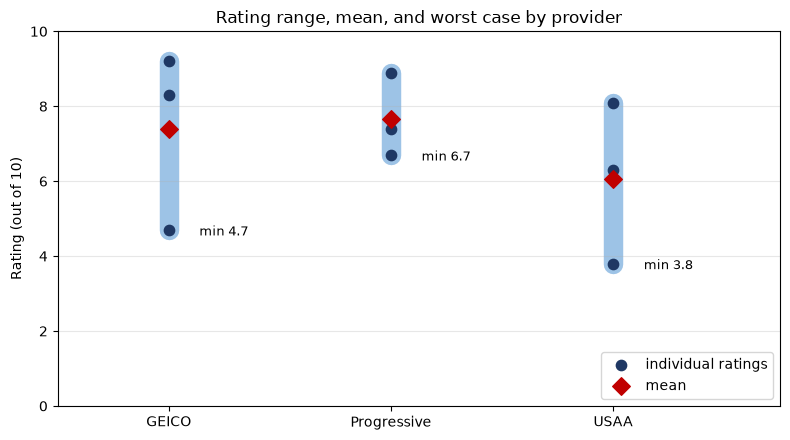

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
providers = summary.index.tolist()

for i, p in enumerate(providers):
    lo, hi = summary.loc[p, "min"], summary.loc[p, "max"]
    ax.plot([i, i], [lo, hi], color="#9dc3e6", linewidth=14, solid_capstyle="round", zorder=1)
    pts = df.loc[df["provider"] == p, "rating"]
    ax.scatter([i] * len(pts), pts, color="#1f3864", s=55, zorder=3, label="individual ratings" if i == 0 else "")
    ax.scatter([i], [summary.loc[p, "mean"]], color="#c00000", marker="D", s=80, zorder=4, label="mean" if i == 0 else "")
    ax.annotate(f"min {lo}", (i, lo), textcoords="offset points", xytext=(22, -4), fontsize=9)

ax.set_xlim(-0.5, len(providers) - 0.25)
ax.set_xticks(range(len(providers)))
ax.set_xticklabels(providers)
ax.set_ylabel("Rating (out of 10)")
ax.set_ylim(0, 10)
ax.set_title("Rating range, mean, and worst case by provider")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

---

# Written Answer

I would go with Progressive. Its average rating of 7.67 is the highest of the three, but the number that actually decides it for me is its minimum of 6.7, compared to 4.7 for GEICO and 3.8 for USAA. That minimum represents the worst experience a real customer reported, and for insurance specifically the worst case is what matters most, because you deal with your provider at the moment something has already gone wrong in your life. GEICO is the tempting pick here: it has the single highest rating in the table at 9.2 and an average only about a quarter point behind Progressive, so on a quick glance it looks competitive. But that average is being propped up by one excellent review while another customer rated it a 4.7, which means GEICO's quality is inconsistent and your experience depends heavily on luck. Progressive's three ratings all fall in a narrow 6.7 to 8.9 band, so its average is actually representative of what a typical customer gets rather than a blend of very good and very bad outcomes. USAA is out on both counts, with the lowest average and the lowest floor.

### Summary table for reference

| Provider | Min | Mean | Max | Range |
|---|---|---|---|---|
| GEICO | 4.7 | 7.40 | 9.2 | 4.5 |
| **Progressive** | **6.7** | **7.67** | 8.9 | **2.2** |
| USAA | 3.8 | 6.07 | 8.1 | 4.3 |